# 🗣️ Análisis de Sentimiento en Tweets en Español (NLP)

### Procesamiento de Lenguaje Natural de extremo a extremo

| | |
|---|---|
| **Autora** | Karen Alisson Chuquimia Mamani |
| **Área** | Ciencia de Datos · NLP |
| **Datos** | ~2.590 tuits en español etiquetados con emociones |
| **Stack** | Python · scikit-learn · Pandas · Matplotlib · Seaborn |

---

## 🎯 Objetivo

Construir un **clasificador de sentimiento** (positivo / negativo) para tuits escritos en
español, recorriendo el ciclo completo de un proyecto de NLP: carga y EDA, limpieza de
texto, vectorización TF-IDF, modelado, evaluación, interpretabilidad e inferencia.

## 📦 Datos

Uso un dataset real de **tuits en español** (`data/sentiment_analysis_dataset.csv`) que trae
una columna `sentiment` con **6 emociones**. Las agrupo en sentimiento binario:

- **Positivo (1):** `peaceful`, `powerful`, `joyful`
- **Negativo (0):** `mad`, `sad`, `scared`

> Si el archivo de datos no estuviera disponible, el notebook genera un pequeño corpus de
> demostración para poder ejecutarse igual.

In [1]:
# === Librerías ===
import os, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, f1_score, accuracy_score)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Entorno listo")

Entorno listo


## 1 · Carga de datos

El loader es robusto: usa `reviews.csv` si ya está procesado; si no, toma el dataset crudo de
tuits y mapea las 6 emociones a sentimiento binario; y si no hay datos, usa un corpus demo.

In [2]:
POS = {"peaceful", "powerful", "joyful"}
NEG = {"mad", "sad", "scared"}

def generar_corpus_demo(n=300, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    pos = ["me encanto, es genial y util", "excelente, lo recomiendo", "muy bueno, feliz con la compra"]
    neg = ["pesimo, una perdida de dinero", "muy malo, no lo recomiendo", "horrible, me arrepiento"]
    filas = [(rng.choice(pos), 1) for _ in range(n)] + [(rng.choice(neg), 0) for _ in range(n)]
    return pd.DataFrame(filas, columns=["texto", "sentimiento"]).sample(frac=1, random_state=seed).reset_index(drop=True)

# Busca los datos en data/ o ../data/ para funcionar desde la raiz o desde notebooks/
DATA_DIRS = ["data", "../data", "."]
def _buscar(fname):
    for d in DATA_DIRS:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    return None

def cargar_datos():
    rev = _buscar("reviews.csv")
    if rev:
        return pd.read_csv(rev), rev + " (ya procesado)"
    raw = _buscar("sentiment_analysis_dataset.csv")
    if raw:
        d = pd.read_csv(raw, engine="python")[["text", "sentiment"]].dropna()
        s = d["sentiment"].astype(str).str.lower().str.strip()
        d["sentimiento"] = np.where(s.isin(POS), 1, np.where(s.isin(NEG), 0, np.nan))
        d = d.dropna(subset=["sentimiento"])
        out = d.rename(columns={"text": "texto"})[["texto", "sentimiento"]].copy()
        out["sentimiento"] = out["sentimiento"].astype(int)
        out.to_csv(os.path.join(os.path.dirname(raw), "reviews.csv"), index=False)
        return out, "tuits reales (emocion -> binario)"
    return generar_corpus_demo(), "CORPUS DEMO (sintetico)"

df, fuente = cargar_datos()
print("Fuente de datos:", fuente)
print("Forma:", df.shape)
df.head()

Fuente de datos: ../data/reviews.csv (ya procesado)
Forma: (2590, 2)


,texto,sentimiento
0,termine bien abrumado después de hoy,0
1,me siento abrumado,0
2,Me siento un poco abrumado por la cantidad de ...,0
3,Salvador la única persona que no la ha abrumad...,0
4,Denme un helado o algo que ando full abrumado.,0


## 2 · Análisis exploratorio (EDA)

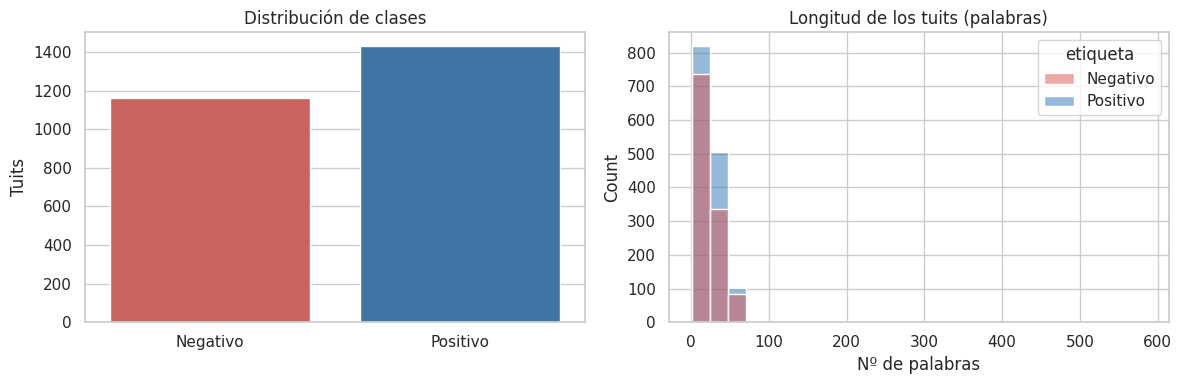

etiqueta
Positivo    1430
Negativo    1160
Name: count, dtype: int64


In [3]:
df["etiqueta"] = df["sentimiento"].map({0: "Negativo", 1: "Positivo"})
df["n_palabras"] = df["texto"].astype(str).str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="etiqueta", hue="etiqueta", palette=["#d9534f", "#2E75B6"], ax=axes[0], legend=False)
axes[0].set_title("Distribución de clases"); axes[0].set_xlabel(""); axes[0].set_ylabel("Tuits")
sns.histplot(data=df, x="n_palabras", hue="etiqueta", palette=["#d9534f", "#2E75B6"], bins=25, ax=axes[1])
axes[1].set_title("Longitud de los tuits (palabras)"); axes[1].set_xlabel("Nº de palabras")
plt.tight_layout(); plt.show()
print(df["etiqueta"].value_counts())

## 3 · Preprocesamiento de texto

Para tuits es clave eliminar **URLs y menciones (@usuario)**. Quitamos tildes, símbolos y
*stopwords*, pero **conservamos las negaciones** (`no`, `nunca`, `sin`), que invierten el
sentimiento.

In [4]:
STOPWORDS_ES = set("""
a al algo algunas algunos ante antes como con contra cual cuando de del desde donde dos durante
e el ella ellas ellos en entre era eran es esa esas ese eso esos esta estas este esto estos fue
fueron ha hace hacia han hasta hay la las le les lo los me mi mis mucho muy nos nuestra nuestro
o os otra otras otro otros para pero poco por porque que quien se sea sobre solo son su sus
tambien te tiene tienen toda todas todo todos tu tus un una uno unos vosotras vosotros y ya yo
q rt jaja jajaja
""".split())

def limpiar(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)   # URLs
    texto = re.sub(r"@\w+", " ", texto)                 # menciones
    texto = texto.replace("#", " ")                      # quita # pero conserva la palabra
    texto = "".join(c for c in unicodedata.normalize("NFD", texto) if unicodedata.category(c) != "Mn")
    texto = re.sub(r"[^a-z\s]", " ", texto)             # solo letras
    return " ".join(t for t in texto.split() if t not in STOPWORDS_ES and len(t) > 1)

df["texto_limpio"] = df["texto"].apply(limpiar)
df = df[df["texto_limpio"].str.len() > 0]
print("Ejemplo:")
print("  Original:", df["texto"].iloc[0])
print("  Limpio  :", df["texto_limpio"].iloc[0])

Ejemplo:
  Original: termine bien abrumado después de hoy
  Limpio  : termine bien abrumado despues hoy


## 4 · División train / test y vectorización TF-IDF

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df["texto_limpio"], df["sentimiento"], test_size=0.25,
    random_state=RANDOM_STATE, stratify=df["sentimiento"])

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=8000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(f"Train: {X_train_vec.shape[0]} tuits · {X_train_vec.shape[1]} features")
print(f"Test : {X_test_vec.shape[0]} tuits")

Train: 1942 tuits · 2485 features
Test : 648 tuits


## 5 · Entrenamiento y comparación de modelos (validación cruzada)

In [6]:
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
    "SVM lineal": LinearSVC(random_state=RANDOM_STATE),
}
res = []
for nombre, m in modelos.items():
    sc = cross_val_score(m, X_train_vec, y_train, cv=5, scoring="f1")
    res.append((nombre, sc.mean(), sc.std()))
    print(f"{nombre:22s}  F1 = {sc.mean():.3f} +/- {sc.std():.3f}")
res_df = pd.DataFrame(res, columns=["Modelo", "F1", "std"]).sort_values("F1", ascending=False)
print("\nMejor modelo:", res_df.iloc[0]["Modelo"])

Regresión Logística     F1 = 0.868 +/- 0.021


Naive Bayes             F1 = 0.876 +/- 0.016
SVM lineal              F1 = 0.902 +/- 0.025

Mejor modelo: SVM lineal


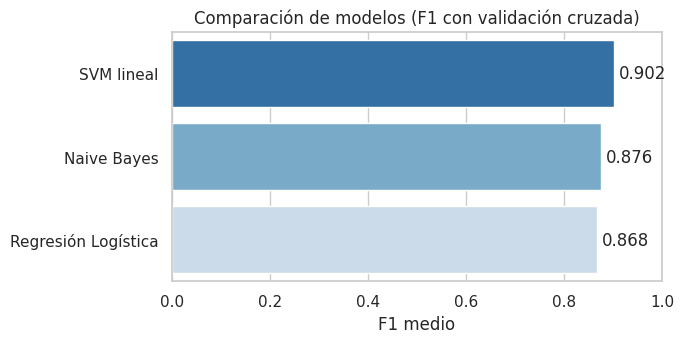

In [7]:
plt.figure(figsize=(7, 3.6))
sns.barplot(data=res_df, y="Modelo", x="F1", hue="Modelo", palette="Blues_r", legend=False)
plt.xlim(0, 1); plt.title("Comparación de modelos (F1 con validación cruzada)"); plt.xlabel("F1 medio"); plt.ylabel("")
for i, v in enumerate(res_df["F1"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()

## 6 · Evaluación del modelo elegido (Regresión Logística)

Aunque el **SVM lineal** obtuvo un F1 ligeramente superior en validación cruzada, elijo la
**Regresión Logística** para la evaluación final porque ofrece **probabilidades** (necesarias
para la curva ROC y la confianza de cada predicción) y **coeficientes interpretables**
(sección 7), con un rendimiento muy cercano.

In [8]:
modelo = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train_vec, y_train)
y_pred = modelo.predict(X_test_vec)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3), "| F1:", round(f1_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, target_names=["Negativo", "Positivo"]))

Accuracy: 0.847 | F1: 0.869

              precision    recall  f1-score   support

    Negativo       0.88      0.77      0.82       290
    Positivo       0.83      0.91      0.87       358

    accuracy                           0.85       648
   macro avg       0.85      0.84      0.84       648
weighted avg       0.85      0.85      0.85       648



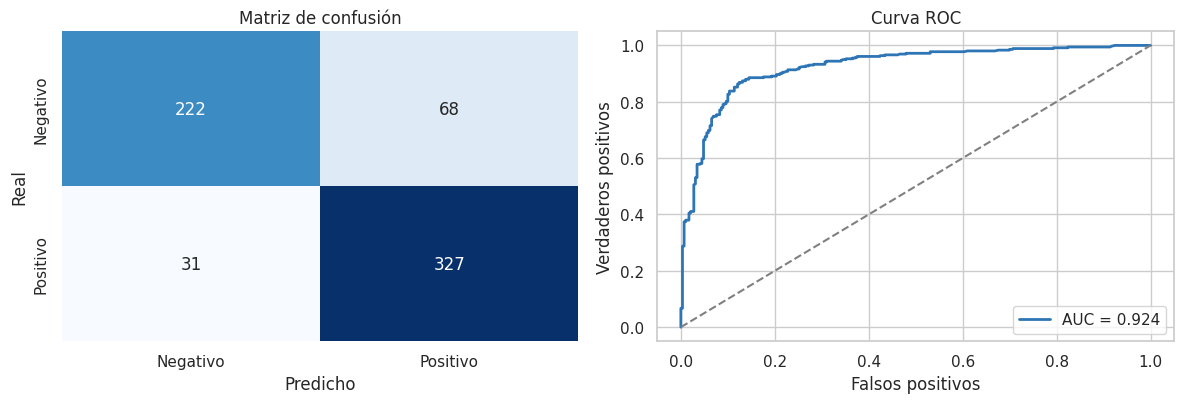

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"], ax=axes[0])
axes[0].set_title("Matriz de confusión"); axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")
y_score = modelo.predict_proba(X_test_vec)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score); roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#2E75B6", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Curva ROC"); axes[1].set_xlabel("Falsos positivos"); axes[1].set_ylabel("Verdaderos positivos"); axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

## 7 · Interpretabilidad: términos más decisivos

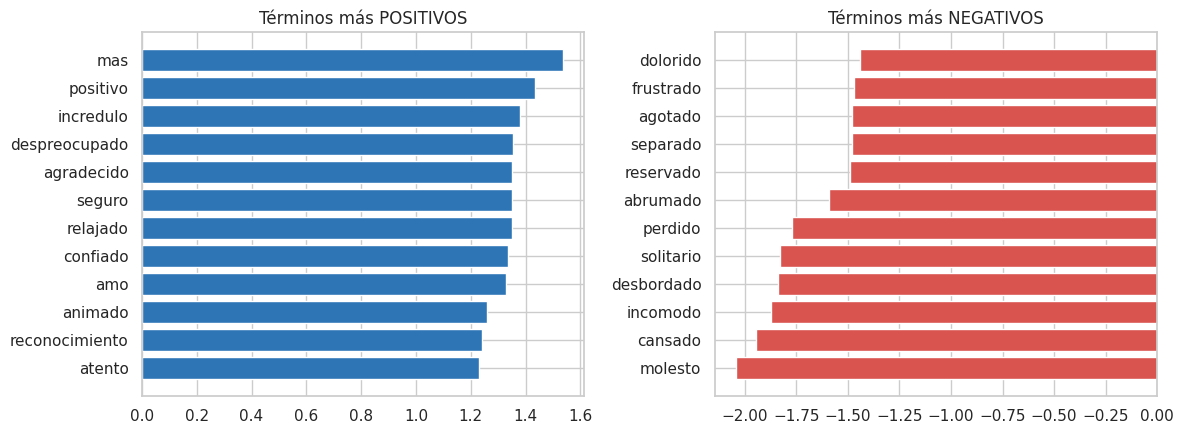

In [10]:
names = np.array(vectorizer.get_feature_names_out())
coefs = modelo.coef_[0]; n = 12
pos_idx = np.argsort(coefs)[-n:]; neg_idx = np.argsort(coefs)[:n]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(names[pos_idx], coefs[pos_idx], color="#2E75B6"); axes[0].set_title("Términos más POSITIVOS")
axes[1].barh(names[neg_idx], coefs[neg_idx], color="#d9534f"); axes[1].set_title("Términos más NEGATIVOS")
plt.tight_layout(); plt.show()

## 8 · Función de inferencia

In [11]:
def predecir_sentimiento(texto):
    v = vectorizer.transform([limpiar(texto)])
    pred = modelo.predict(v)[0]; prob = modelo.predict_proba(v)[0].max()
    return f"{'Positivo' if pred == 1 else 'Negativo'}  (confianza: {prob:.0%})"

for e in ["que dia tan maravilloso, me siento pleno y feliz",
          "estoy harto de todo, esto es un desastre",
          "me siento tranquilo y en paz",
          "tengo mucho miedo y angustia"]:
    print(f"{predecir_sentimiento(e)}  <-  {e}")

Positivo  (confianza: 66%)  <-  que dia tan maravilloso, me siento pleno y feliz
Negativo  (confianza: 75%)  <-  estoy harto de todo, esto es un desastre
Positivo  (confianza: 65%)  <-  me siento tranquilo y en paz
Positivo  (confianza: 77%)  <-  tengo mucho miedo y angustia


## 9 · Conclusiones y próximos pasos

**Logrado**
- Pipeline de NLP de extremo a extremo sobre **tuits reales en español**: limpieza específica de
  Twitter → TF-IDF → modelado → evaluación → interpretabilidad.
- La Regresión Logística ofrece buen rendimiento y, sobre todo, **explicabilidad**.

**Próximos pasos**
1. Clasificación **multiclase** de las 6 emociones originales.
2. Probar **Transformers en español** (BETO, RoBERTa-es).
3. **Desplegar** como API (FastAPI) o app interactiva (Streamlit).

---
*Proyecto desarrollado por Karen Chuquimia · Portafolio de Ciencia de Datos / NLP.*